In [1]:
%matplotlib inline

ModuleNotFoundError: No module named 'matplotlib'

In [2]:
import pandas as pd


### Heading 3
- point 1
- point 2

1. n1
2. n3

*Italic*

**Bold**

In [3]:
from datetime import datetime as d
df = pd.DataFrame({
        'first_name': ['Aleksandra', 'Tomek', 'Konrad', 'Katarzyna', 'Jan', 'Tomek'],
        'last_name': ['Nowak', 'Kowalski', 'Lewandowski', 'Woźniak', 'Wiśniewska', 'Błaszczykowski'],
        'gender': ['female', 'male', 'male', 'female', 'male', 'male'],
        'date_of_birth': [d(1988, 1, 10), d(1938, 10, 22), d(1986, 11, 20), 
                          d(1980, 2, 12), d(1978, 5, 21), d(1960, 3, 1)],
        'rate': [100, 90, 50, 110, 170, 40],
        'hours': [60, 20, 100, 50, 160, 70],
    },
    columns=('first_name', 'last_name', 'gender', 'date_of_birth', 'rate', 'hours'),
)

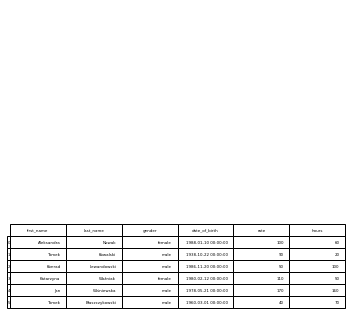

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
from pandas.plotting import table 

ax = plt.subplot(111, frame_on=False) # no visible frame
ax.xaxis.set_visible(False)  # hide the x axis
ax.yaxis.set_visible(False)  # hide the y axis

table(ax, df)  # where df is your data frame

plt.savefig('mytable.png')

In [4]:
df

,first_name,last_name,gender,date_of_birth,rate,hours
0,Aleksandra,Nowak,female,1988-01-10,100,60
1,Tomek,Kowalski,male,1938-10-22,90,20
2,Konrad,Lewandowski,male,1986-11-20,50,100
3,Katarzyna,Woźniak,female,1980-02-12,110,50
4,Jan,Wiśniewska,male,1978-05-21,170,160
5,Tomek,Błaszczykowski,male,1960-03-01,40,70


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   first_name     6 non-null      str           
 1   last_name      6 non-null      str           
 2   gender         6 non-null      str           
 3   date_of_birth  6 non-null      datetime64[us]
 4   rate           6 non-null      int64         
 5   hours          6 non-null      int64         
dtypes: datetime64[us](1), int64(2), str(3)
memory usage: 420.0 bytes


In [6]:
df.describe()

,date_of_birth,rate,hours
count,6,6.000000,6.000000
mean,1972-01-24 04:00:00,93.333333,76.666667
min,1938-10-22 00:00:00,40.000000,20.000000
25%,1964-09-19 18:00:00,60.000000,52.500000
50%,1979-04-02 00:00:00,95.000000,65.000000
75%,1985-03-11 18:00:00,107.500000,92.500000
max,1988-01-10 00:00:00,170.000000,160.000000
std,NaN,46.761808,48.442406


In [7]:
df[df.gender == 'male']

,first_name,last_name,gender,date_of_birth,rate,hours
1,Tomek,Kowalski,male,1938-10-22,90,20
2,Konrad,Lewandowski,male,1986-11-20,50,100
4,Jan,Wiśniewska,male,1978-05-21,170,160
5,Tomek,Błaszczykowski,male,1960-03-01,40,70


In [13]:
df[df.first_name.isin(['Jan', 'Tomek'])]

,first_name,last_name,gender,date_of_birth,rate,hours
1,Tomek,Kowalski,male,1938-10-22,90,20
4,Jan,Wiśniewska,male,1978-05-21,170,160
5,Tomek,Błaszczykowski,male,1960-03-01,40,70


In [8]:
df[(df.gender == 'male') & (df.date_of_birth.dt.year > 1970)]

,first_name,last_name,gender,date_of_birth,rate,hours
2,Konrad,Lewandowski,male,1986-11-20,50,100
4,Jan,Wiśniewska,male,1978-05-21,170,160


In [15]:
df['per_month'] = df.rate * df.hours
df

,first_name,last_name,gender,date_of_birth,rate,hours,per_month
0,Aleksandra,Nowak,female,1988-01-10,100,60,6000
1,Tomek,Kowalski,male,1938-10-22,90,20,1800
2,Konrad,Lewandowski,male,1986-11-20,50,100,5000
3,Katarzyna,Woźniak,female,1980-02-12,110,50,5500
4,Jan,Wiśniewska,male,1978-05-21,170,160,27200
5,Tomek,Błaszczykowski,male,1960-03-01,40,70,2800


In [18]:
df.sort_values('per_month', ascending=False, inplace=True)
df

,first_name,last_name,gender,date_of_birth,rate,hours,per_month
4,Jan,Wiśniewska,male,1978-05-21,170,160,27200
0,Aleksandra,Nowak,female,1988-01-10,100,60,6000
3,Katarzyna,Woźniak,female,1980-02-12,110,50,5500
2,Konrad,Lewandowski,male,1986-11-20,50,100,5000
5,Tomek,Błaszczykowski,male,1960-03-01,40,70,2800
1,Tomek,Kowalski,male,1938-10-22,90,20,1800


In [19]:
df.rate.sum() / df.rate.count()

np.float64(93.33333333333333)

In [20]:
df.rate.mean()

np.float64(93.33333333333333)

In [21]:
rate_stats = df.groupby('gender').aggregate({'rate': sum, 'gender': 'count'})

In [22]:
rate_stats

,rate,gender
gender,,
female,210,2
male,350,4


In [24]:
rate_for_gender = rate_stats.rate / rate_stats.gender
rate_for_gender

gender
female    105.0
male       87.5
dtype: float64

<Axes: xlabel='gender'>

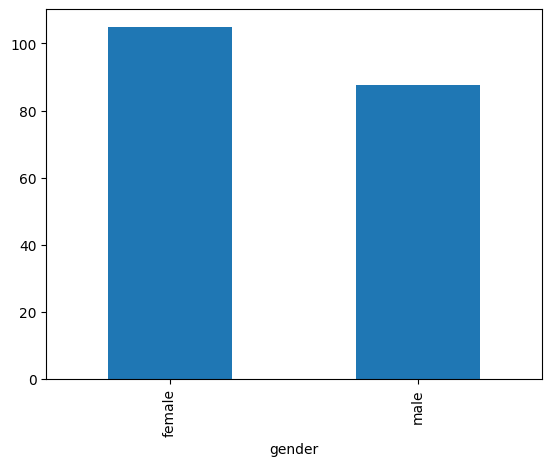

In [25]:
rate_for_gender.plot(kind='bar')

In [26]:
df.rate

4    170
0    100
3    110
2     50
5     40
1     90
Name: rate, dtype: int64

In [27]:
def rate_level(rate):
    if rate < 60:
        return '1: <60'
    elif 60 <= rate < 120:
        return '2: 60-120'
    else:
        return '3: >120'

In [28]:
df['rate_level'] = df.rate.apply(rate_level)

In [29]:
df

,first_name,last_name,gender,date_of_birth,rate,hours,per_month,rate_level
4,Jan,Wiśniewska,male,1978-05-21,170,160,27200,3: >120
0,Aleksandra,Nowak,female,1988-01-10,100,60,6000,2: 60-120
3,Katarzyna,Woźniak,female,1980-02-12,110,50,5500,2: 60-120
2,Konrad,Lewandowski,male,1986-11-20,50,100,5000,1: <60
5,Tomek,Błaszczykowski,male,1960-03-01,40,70,2800,1: <60
1,Tomek,Kowalski,male,1938-10-22,90,20,1800,2: 60-120


<Axes: xlabel='rate_level'>

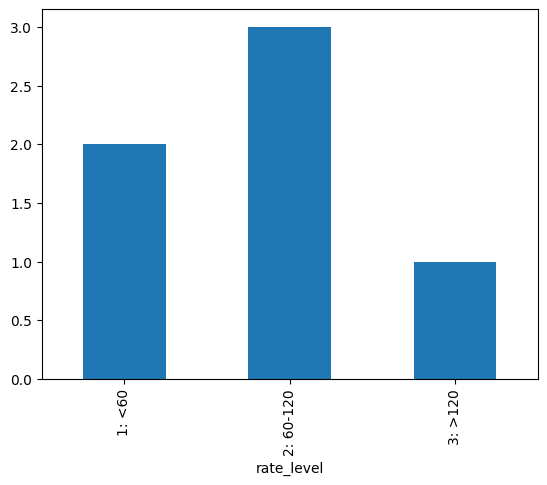

In [30]:
df.rate_level.value_counts().sort_index().plot(kind='bar')

In [31]:
df[df.per_month < 5000]

,first_name,last_name,gender,date_of_birth,rate,hours,per_month,rate_level
1,Tomek,Kowalski,male,1938-10-22,90,20,1800,2: 60-120
5,Tomek,Błaszczykowski,male,1960-03-01,40,70,2800,1: <60


In [1]:
import os
os.getcwd()
df.df

'C:\\Users\\mgrze\\OneDrive\\ML'